# Parte 4 — Experimento B: BERTweet
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `vinai/bertweet-base`  
**Pre-entrenamiento:** 850M tweets en inglés  
**Tokenizador:** BPE entrenado sobre texto de Twitter

BERTweet tiene la misma arquitectura que BERT-base (12 capas, 768 dimensiones, ~110M parámetros), pero fue pre-entrenado desde cero sobre tweets.

> **Nota sobre `normalization=True`:** el tokenizador normaliza las URLs a `HTTPURL` y los @mentions a `@USER` antes de tokenizar, replicando el preprocesamiento usado durante el pre-entrenamiento.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [17]:
%run tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [18]:
MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "asilvaz/tweeteval-emotion-bertweet"  # <-- cambia esto
LR               = 5e-5

### 📝 TODO 4.1 — Tokenizar el dataset con BERTweet

Importante: carga el tokenizador con `normalization=True`.

In [19]:
# TODO 4.1 ── Tokenizar con BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# Carga el tokenizador con normalization=True y tokeniza el dataset
# Guarda el resultado en ds_bertweet

# YOUR CODE HERE
tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet = make_tokenized_dataset(tok_bertweet)

print(ds_bertweet)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 4.2 — Cargar el modelo BERTweet

Mismo procedimiento que con DistilBERT pero con `MODEL_CHECKPOINT`. Imprime el número de parámetros y compáralo con DistilBERT.

In [20]:
# TODO 4.2 ── Cargar BERTweet para clasificación
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
model_bertweet = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID)

# Imprimir numero de parámetros
print(f'\nNúmero de parámetros en BERTweet: {model_bertweet.num_parameters()} vs DistilBERT: 66956548')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi


Número de parámetros en BERTweet: 134903044 vs DistilBERT: 66956548


### 📝 TODO 4.3 — Entrenar y evaluar BERTweet

Repite el mismo proceso del TODO 3.3 con el modelo y dataset de BERTweet.

**Pregunta:** ¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?

No es el todo necesario, porque ambos modelos tienen buen rendimiento. Sin embargo, al ser BERTweet entrenado con tweets, similares al dataset, puede ser empujado a un lr más agresivo. En este caso se eligió 5e-5.

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.728582,0.572801,0.751121,0.807487
2,0.476738,0.626253,0.734926,0.791444
3,0.353882,0.563514,0.757990,0.810160
4,0.224703,0.558988,0.760214,0.812834
5,0.150296,0.589990,0.790275,0.834225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

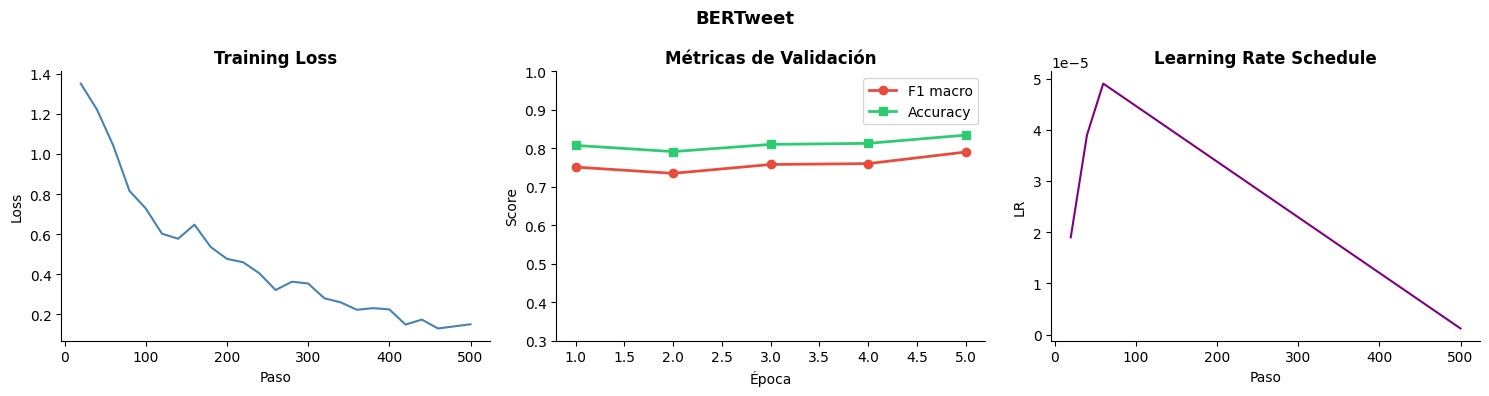


  Test — BERTweet
              precision    recall  f1-score   support

       anger     0.8689    0.8907    0.8796       558
         joy     0.8844    0.8547    0.8693       358
    optimism     0.7850    0.6829    0.7304       123
     sadness     0.8232    0.8534    0.8380       382

    accuracy                         0.8536      1421
   macro avg     0.8404    0.8204    0.8294      1421
weighted avg     0.8533    0.8536    0.8529      1421



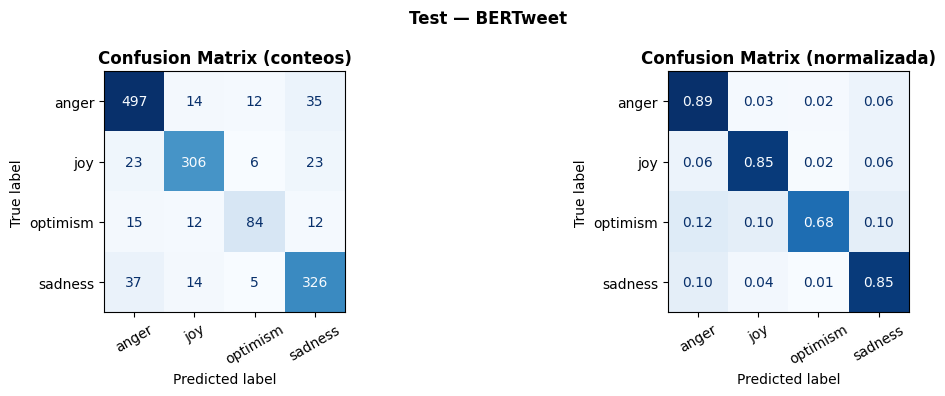

In [22]:
# TODO 4.3 ── Entrenamiento de BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# Guarda los resultados en metrics_bertweet y el trainer en trainer_bertweet

# YOUR CODE HERE
# 1. Crear trainer
trainer_bertweet = make_trainer(
    model=model_bertweet,
    tokenizer=tok_bertweet,
    tokenized_ds=ds_bertweet,
    output_dir="./checkpoints/bertweet",
    lr=LR,
    hub_model_id=HF_REPO
)

# 2. Entrenar
trainer_bertweet.train()

# 3. Curvas de entrenamiento
plot_training_curves(trainer_bertweet, title="BERTweet")

# 4. Evaluación en test
metrics_bertweet = full_evaluation(trainer_bertweet, ds_bertweet["test"], model_name="BERTweet")


## Push to Hub

In [23]:
trainer_bertweet.push_to_hub(
    commit_message="BERTweet fine-tuning — TweetEval emotion"
    )
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo publicado en: https://huggingface.co/asilvaz/tweeteval-emotion-bertweet
